# Experiments on the ETH-USD dataset with prices

In [1]:
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)

In [2]:
from src.models import (
    LSTMForecaster, 
    MLPForecaster, 
    LinearForecaster, 
    NaiveGaussian, 
    NaiveBootstrap, 
    TransfomerForecaster, 
    GPForecaster,
)
import torch
import matplotlib.pyplot as plt
from eth_utils import plot_forecast, print_metrics
import pandas as pd
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## Download data

In [3]:
binance_ethusd_2024 = pd.read_csv('../data/raw/Binance_ETHUSDT_2024_minute.csv', skiprows=1)
binance_ethusd_2024.Date = pd.to_datetime(binance_ethusd_2024.Date)
binance_ethusd_2024 = binance_ethusd_2024.sort_values(by='Date')
binance_ethusd_2024 = binance_ethusd_2024.set_index('Date')
binance_ethusd_2024 = binance_ethusd_2024[['High', 'Low']]
binance_ethusd_2024.head()

,High,Low
Date,,
2024-01-01 00:00:00,2282.94,2281.27
2024-01-01 00:01:00,2283.97,2282.20
2024-01-01 00:02:00,2284.60,2283.80
2024-01-01 00:03:00,2286.43,2284.38
2024-01-01 00:04:00,2287.84,2286.37


In [4]:
binance_ethusd_2024.shape

(526738, 2)

In [5]:
l = len(binance_ethusd_2024)
target = binance_ethusd_2024.values
split = 0.7

In [6]:
scaler = StandardScaler()
target[:int(l*split)] = scaler.fit_transform(target[:int(l*split)])
target[int(l*split):] = scaler.transform(target[int(l*split):])

In [7]:
target = torch.tensor(target, dtype=torch.float32)
train_target = target[:int(l*split)]
test_target = target[int(l*split):]

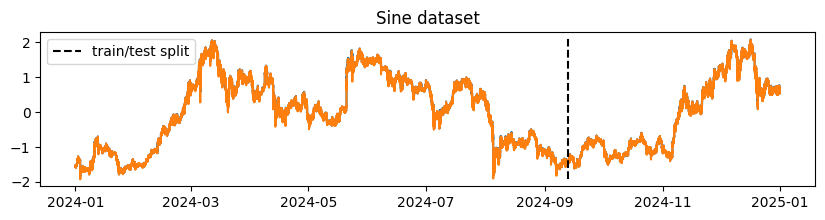

In [8]:
min_, max_ = target.min(), target.max()
plt.figure(figsize=(10, 2))
plt.plot(binance_ethusd_2024.index, target)
plt.vlines(binance_ethusd_2024.index[int(l*split)], min_, max_, linestyles='dashed', color='black', label='train/test split')
plt.title('Sine dataset')
plt.legend()
plt.show()

## LSTM

In [9]:
model = LSTMForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/lstm_prices_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    num_layers=1,
    lr=0.001, 
    hidden_dim=128,
)

In [10]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

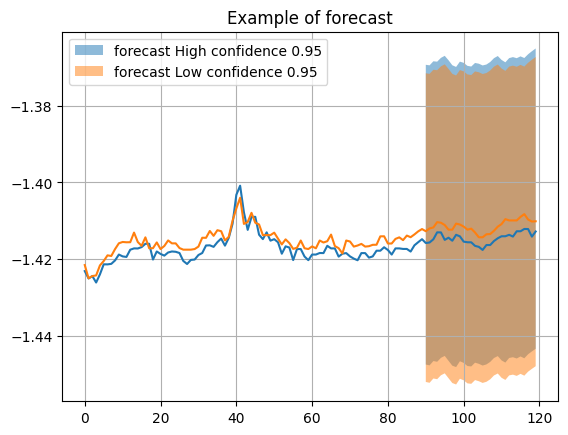

PICP: 0.9523
ECE: 0.0023
CRPS: 0.1219


In [11]:
plot_forecast(model, test_dataset, idx=0)
lstm_metrics = print_metrics(model, test_dataset)

## MLP

In [12]:
model = MLPForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/mlp_prices_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    lr=0.01, 
    num_layers=1,
    hidden_dim=128,
)
model

MLPForecaster(
  (model): MLPModule(
    (mlp): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=4, bias=True)
    )
  )
)

In [13]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

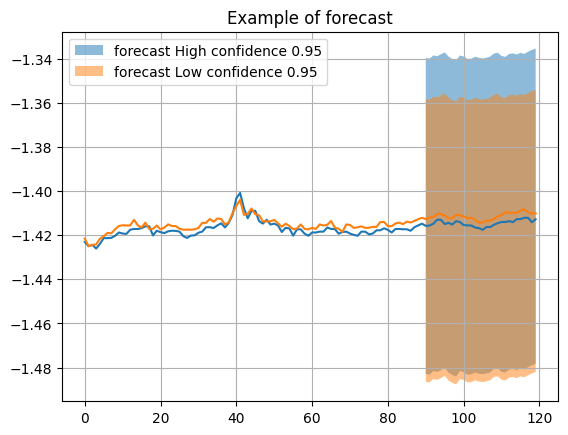

PICP: 0.9506
ECE: 0.0006
CRPS: 0.1553


In [14]:
plot_forecast(model, test_dataset, idx=0)
mlp_metrics = print_metrics(model, test_dataset)

## Linear

In [15]:
model = LinearForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/linear_prices_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    lr=0.01,
)
model

LinearForecaster(
  (model): LinearModule(
    (linear): Linear(in_features=2, out_features=4, bias=True)
  )
)

In [16]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

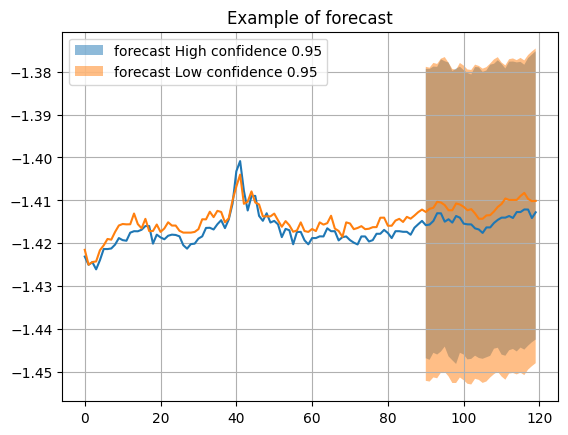

PICP: 0.9316
ECE: 0.0184
CRPS: 0.1024


In [17]:
plot_forecast(model, test_dataset, idx=0)
linear_metrics = print_metrics(model, test_dataset)

## Naive Gaussian

In [18]:
model = NaiveGaussian(
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
)
model

NaiveGaussian()

In [19]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

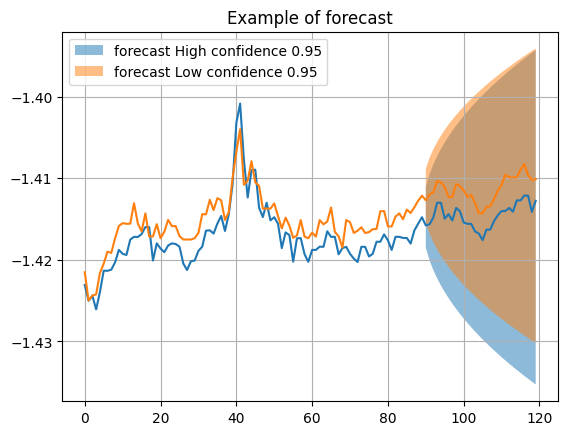

PICP: 0.9139
ECE: 0.0361
CRPS: 0.0616


In [20]:
plot_forecast(model, test_dataset, idx=0)
naive_gaussian_metrics = print_metrics(model, test_dataset)

## Naive Bootstrap

In [21]:
model = NaiveBootstrap(
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    num_samples=1000,
)
model

NaiveBootstrap()

In [22]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

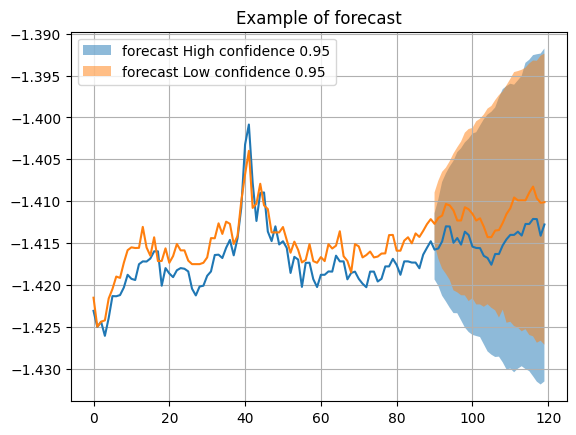

  0%|          | 0/158 [00:00<?, ?it/s]

PICP: 0.8876
ECE: 0.0624
CRPS: 0.0615


In [23]:
plot_forecast(model, test_dataset, idx=0)
naive_bootstrap_metrics = print_metrics(model, test_dataset, batch_size=1000)

## Transformer

In [24]:
model = TransfomerForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/transformer_prices_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=5,
    lr=0.001,
    num_layers=2,
    d_model=64,
    num_heads=1,
    dim_feedforward=128,
    dropout=0.,
)
model

TransfomerForecaster(
  (model): TransformerEncoderModule(
    (input_projection): Linear(in_features=2, out_features=64, bias=True)
    (positional_encoding): PositionalEncoding()
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (output_projection): Linear(in_features=64, out_features=4, bias=True)
 

In [25]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

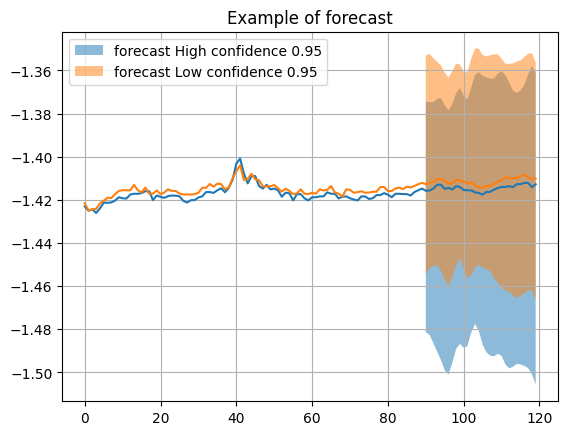

PICP: 0.9094
ECE: 0.0406
CRPS: 0.1060


In [26]:
plot_forecast(model, test_dataset, idx=0)
transformer_metrics = print_metrics(model, test_dataset)

## Gaussian process

In [27]:
model = GPForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/gp_prices_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    lr=0.01,
    num_inducing=100,
)
model

GPForecaster(
  (model): GPModule(
    (mean_linear): Linear(in_features=100, out_features=2, bias=True)
    (var_linear): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [28]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

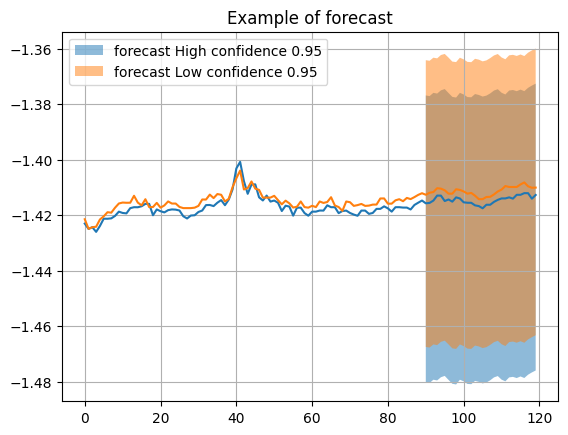

PICP: 0.9497
ECE: 0.0003
CRPS: 0.1233


In [29]:
plot_forecast(model, test_dataset, idx=0)
gp_metrics = print_metrics(model, test_dataset)

## Results

In [32]:
pd.DataFrame({
    'LSTM': lstm_metrics,
    'MLP': mlp_metrics,
    'Linear': linear_metrics,
    'Naive Gaussian': naive_gaussian_metrics,
    'Naive Bootstrap': naive_bootstrap_metrics,
    'Transformer': transformer_metrics,
    'Gaussian process': gp_metrics,
}).T.round(4)

,picp,ece,crps
LSTM,0.9523,0.0023,0.1219
MLP,0.9506,0.0006,0.1553
Linear,0.9316,0.0184,0.1024
Naive Gaussian,0.9139,0.0361,0.0616
Naive Bootstrap,0.8876,0.0624,0.0615
Transformer,0.9094,0.0406,0.1060
Gaussian process,0.9497,0.0003,0.1233
